# Demonstration Notebook
*Analyzing the National Tunnel Inventory with Marimo notebooks and altair for deploying a reactive analysis app.*
***

In [ ]:
import marimo as mo
import pandas as pd
import altair as alt

## Fetch NTI Dataset

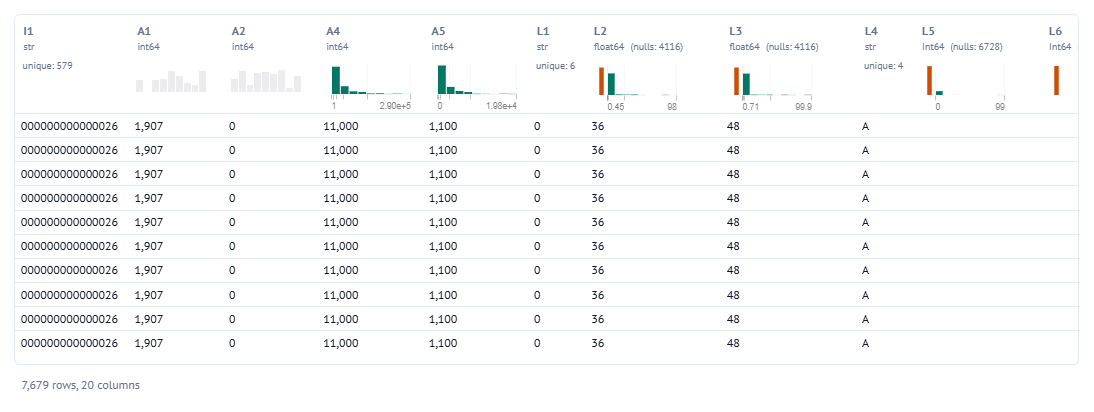

In [ ]:
import duckdb as ddb

df = ddb.sql(f"""
    SELECT 
        tunnels.I1,
        A1,
        A2,
        A4,
        A5,
        L1,
        L2,
        L3,
        L4,
        L5,
        L6,
        L7,
        L8,
        L9,
        EN,
        CS1::INTEGER AS CS1,
        CS2::INTEGER AS CS2,
        CS3::INTEGER AS CS3,
        CS4::INTEGER AS CS4,
        TOTALQTY::INTEGER AS TOTALQTY

    FROM 'tunnels.csv'
        INNER JOIN 'elements.csv'
        ON tunnels.I1 = elements.I1;
    """).df()

df

## Interactive Tool

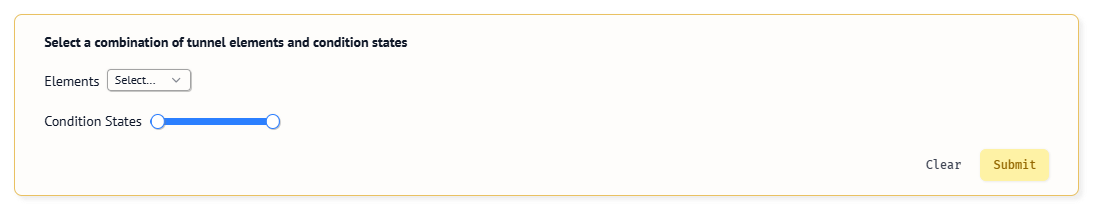

In [ ]:
# Calculate element condition percentages
df['PCT_CS1'] = df.CS1 / df.TOTALQTY
df['PCT_CS2'] = df.CS2 / df.TOTALQTY
df['PCT_CS3'] = df.CS3 / df.TOTALQTY
df['PCT_CS4'] = df.CS4 / df.TOTALQTY

EN_options = df.EN.unique()

# Create a form with multiple elements.
# User must submit the form for a plot to be generated.
form = (
    mo.md('''
    **Select a combination of tunnel elements and condition states**

    {elems}

    {conds}
''')
    .batch(
        elems=mo.ui.multiselect(options=EN_options, label="Elements"),
        conds=mo.ui.range_slider(start=1, stop=4, step=1, label="Condition States"),
    )
    .form(show_clear_button=True, bordered=True)
)

form

In [ ]:
_df = df

if (form.value != None):
    _df = _df[_df.EN.isin(form.value["elems"])].copy()
    fetched_ids = _df.I1

    # Calculate the number of truck cycles experienced
    _df['RECENT_WORK'] = _df[['A1','A2']].max(axis=1).astype(int)
    _df['AGE']  = 2026 - _df.RECENT_WORK.astype(int)
    _df['ADTT'] = _df.A5.astype(int)
    _df['TRUCK_CYCLES'] = _df.ADTT * _df.AGE

    # Aggregate the condition states
    _cols = []
    for _cond in (form.value["conds"]):
        _cols.append(f"PCT_CS{_cond}")
        _colname = " + ".join(_cols)
        _df[_colname] = _df[_cols].sum(axis=1)

    fig1 = mo.ui.altair_chart(alt.Chart(_df).mark_point().encode(
        x='TRUCK_CYCLES',
        y=_colname,
        color='EN'
    ))

In [ ]:
# Display the plot
try:
    mo.vstack([
        mo.md("### Reactive Scatterplot"),
        mo.md("Tip: *Select one or more data points in the chart to show these records in the table.*"),
        fig1, 
        mo.ui.table(fig1.value)
    ])
except:
    mo.md("Please select one or more elements from the dropdown and click 'Submit' to view the chart.")